Successfully loaded data from 'race_summary'.
Generating visualizations...


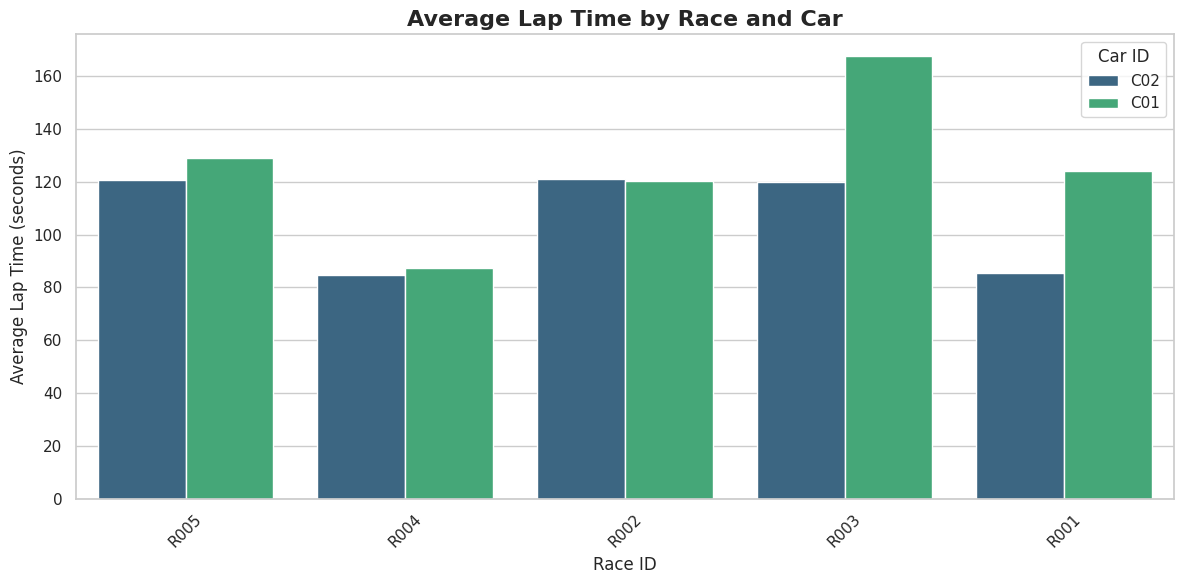

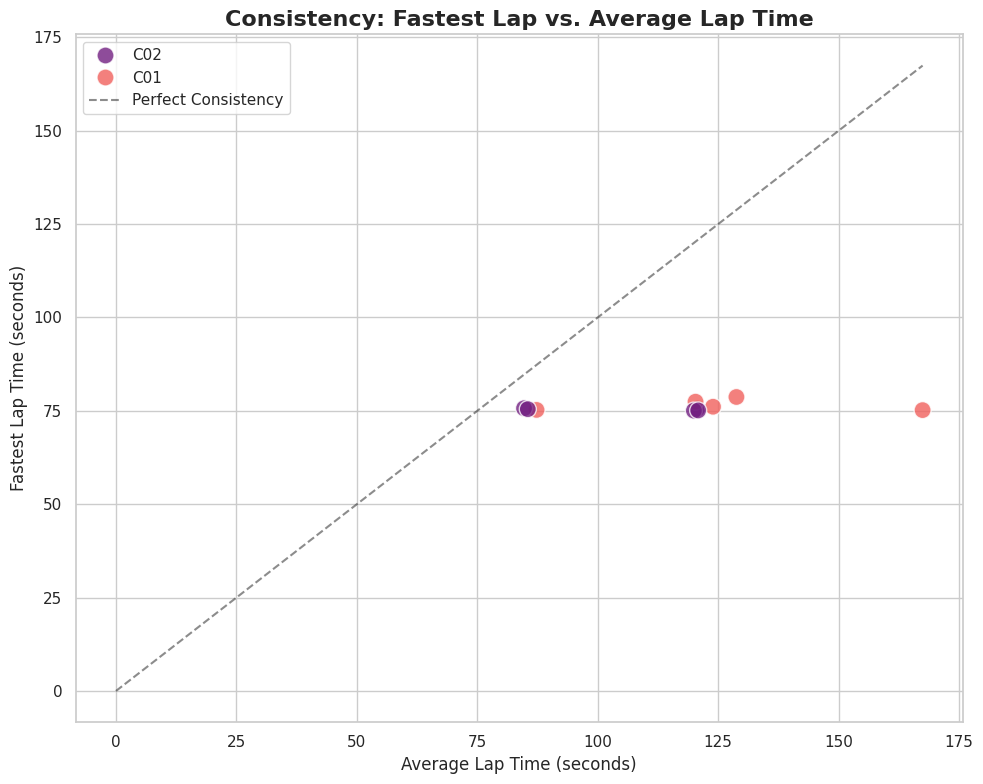


Visualizations generated successfully.


In [0]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Configuration
catalog_name = "shivam_catalog_f1_project"
gold_schema = "gold"
table_name = "race_summary"

# Set a professional plot style
sns.set_theme(style="whitegrid")

# 2. Load the Gold Layer Data
try:
    # Read the summary table from Unity Catalog
    race_summary_spark_df = spark.read.table(f"{catalog_name}.{gold_schema}.{table_name}")
    
    # Convert to Pandas DataFrame for visualization
    # Using .toPandas() is safe here because the summary table is small and aggregated
    race_summary_pd_df = race_summary_spark_df.toPandas()
    
    print(f"Successfully loaded data from '{table_name}'.")
    print("Generating visualizations...")

except Exception as e:
    print(f"❌ Failed to read data. Error: {e}")
    # Stop execution if data cannot be loaded
    dbutils.notebook.exit("Failed to read source gold table.")

# = a helper function in Databricks to render plots
# 3. Create Visualizations

# --- Visualization 1: Average Lap Time Comparison ---
# This chart compares the overall pace of each car across different races.
plt.figure(figsize=(12, 6))
sns.barplot(data=race_summary_pd_df, x="race_id", y="average_lap_time", hue="car_id", palette="viridis")
plt.title('Average Lap Time by Race and Car', fontsize=16, fontweight='bold')
plt.xlabel('Race ID', fontsize=12)
plt.ylabel('Average Lap Time (seconds)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Car ID')
plt.tight_layout()
display(plt.gcf()) # display() is the Databricks function to show plots
plt.close()



# --- Visualization 3: Fastest Lap vs. Average Lap ---
# This scatter plot helps identify consistency. Cars closer to the diagonal line
# have a smaller gap between their average pace and their peak pace.
plt.figure(figsize=(10, 8))
sns.scatterplot(data=race_summary_pd_df, x="average_lap_time", y="fastest_lap_time", hue="car_id", s=150, alpha=0.8, palette="magma")
plt.title('Consistency: Fastest Lap vs. Average Lap Time', fontsize=16, fontweight='bold')
plt.xlabel('Average Lap Time (seconds)', fontsize=12)
plt.ylabel('Fastest Lap Time (seconds)', fontsize=12)
# Add a line for reference where x=y
max_val = race_summary_pd_df[['average_lap_time', 'fastest_lap_time']].max().max()
plt.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='Perfect Consistency')
plt.legend()
plt.tight_layout()
display(plt.gcf())
plt.close()

print("\nVisualizations generated successfully.")

Successfully loaded Gold layer data. Generating enhanced visualizations...


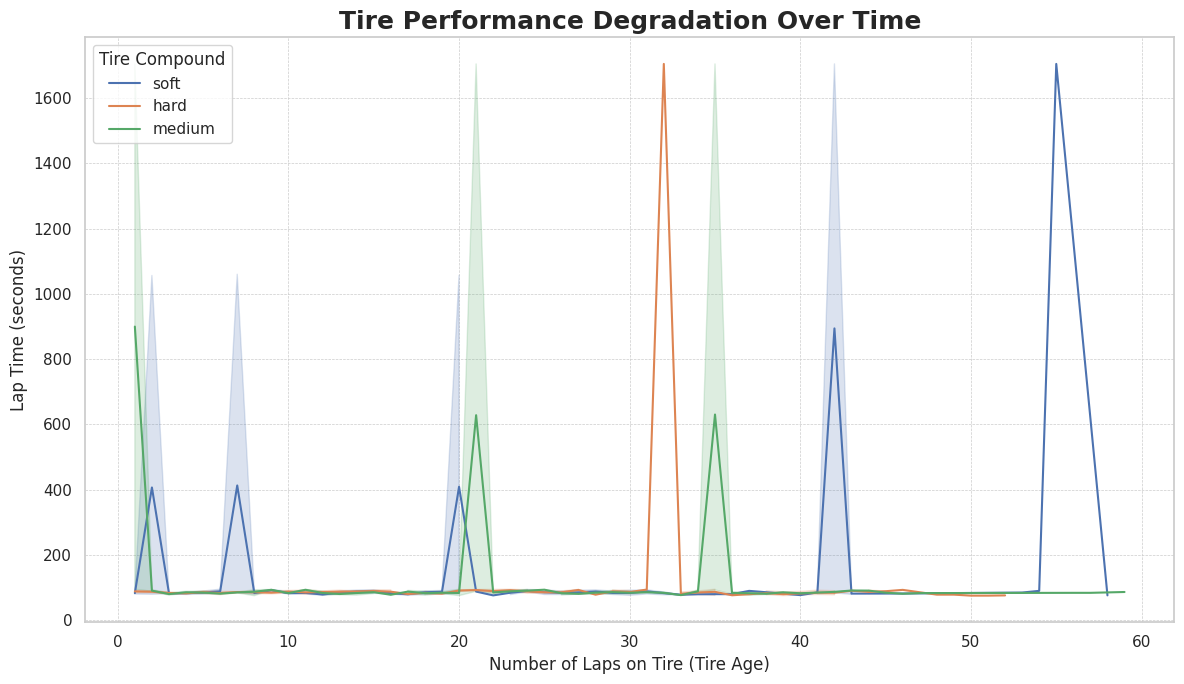

... Viz 1: Tire Degradation plot generated.


/home/spark-30641313-fccf-43d7-a6f9-f1/.ipykernel/1612/command-6133664608453045-2457510827:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=features_df, x="car_id", y="lap_time", palette="muted")


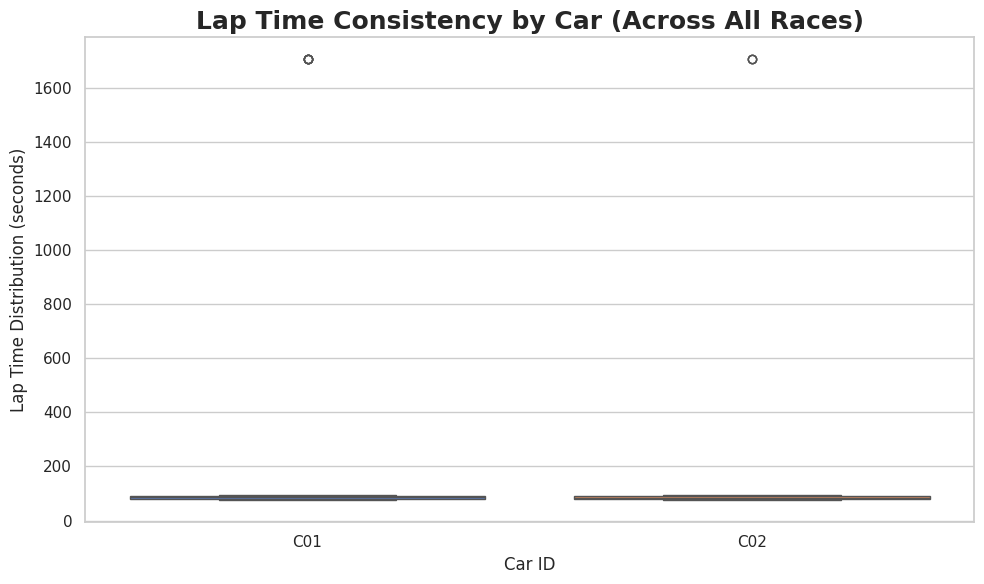

... Viz 2: Lap Time Consistency plot generated.


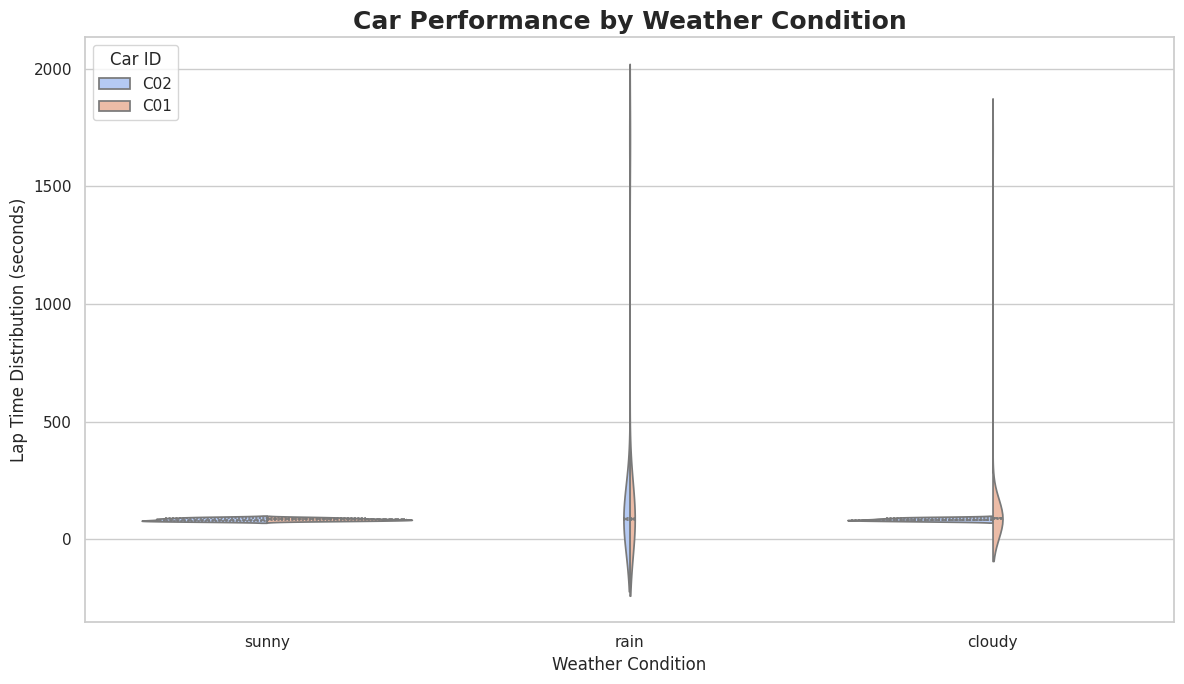

... Viz 3: Weather Performance plot generated.


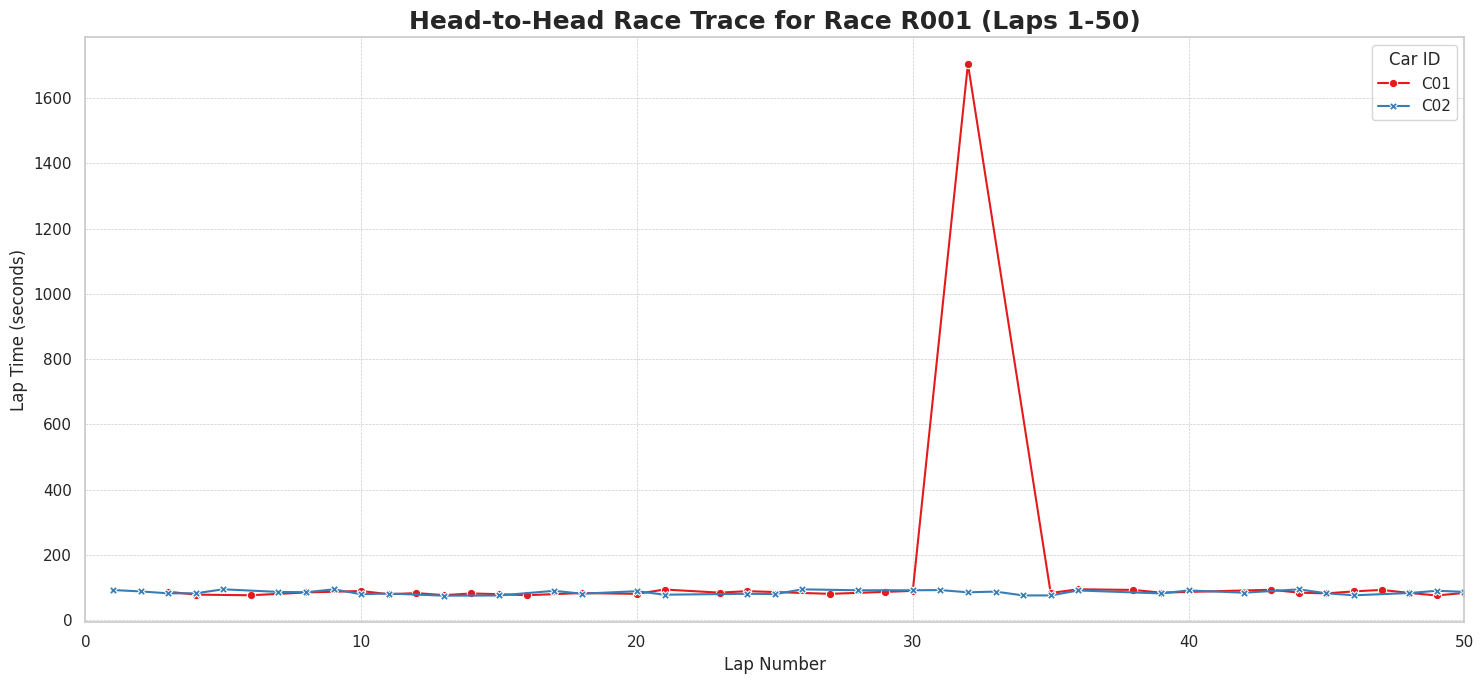

... Viz 4: Focused Race Trace plot generated.


In [0]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Configuration
catalog_name = "shivam_catalog_f1_project"
gold_schema = "gold"
silver_schema = "silver"

# Set a professional plot style for better presentation
sns.set_theme(style="whitegrid", palette="deep")

# 2. Load Data from Unity Catalog
try:
    # Load lap-by-lap feature data for detailed analysis
    features_df = spark.read.table(f"{catalog_name}.{gold_schema}.pit_stop_features").toPandas()
    
    # Load summary data for high-level views
    summary_df = spark.read.table(f"{catalog_name}.{gold_schema}.race_summary").toPandas()
    
    print("Successfully loaded Gold layer data. Generating enhanced visualizations...")

except Exception as e:
    print(f"❌ Failed to read data. Ensure the Gold layer tables exist. Error: {e}")
    dbutils.notebook.exit("Failed to read source gold table.")

# ==============================================================================
# Visualization 1: Tire Degradation Analysis
# Insight: This is the most crucial chart for pit strategy. It shows how lap times 
# increase as tires get older. The steeper the line, the faster the tire wears out.
# ==============================================================================
plt.figure(figsize=(12, 7))
sns.lineplot(data=features_df, x="tire_age_laps", y="lap_time", hue="tire_compound", errorbar=('ci', 95))
plt.title('Tire Performance Degradation Over Time', fontsize=18, fontweight='bold')
plt.xlabel('Number of Laps on Tire (Tire Age)', fontsize=12)
plt.ylabel('Lap Time (seconds)', fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(title='Tire Compound', fontsize=11)
plt.tight_layout()
display(plt.gcf())
plt.close()
print("... Viz 1: Tire Degradation plot generated.")

# ==============================================================================
# Visualization 2: Lap Time Consistency & Distribution
# Insight: This shows the consistency of each car. A shorter box means the car's 
# lap times are very consistent. A taller box means performance is more erratic.
# ==============================================================================
plt.figure(figsize=(10, 6))
sns.boxplot(data=features_df, x="car_id", y="lap_time", palette="muted")
plt.title('Lap Time Consistency by Car (Across All Races)', fontsize=18, fontweight='bold')
plt.xlabel('Car ID', fontsize=12)
plt.ylabel('Lap Time Distribution (seconds)', fontsize=12)
plt.tight_layout()
display(plt.gcf())
plt.close()
print("... Viz 2: Lap Time Consistency plot generated.")

# ==============================================================================
# Visualization 3: Performance in Different Weather Conditions
# Insight: Answers the question "Which car is better in the rain?". This helps in 
# predicting performance if the weather is expected to change mid-race.
# ==============================================================================
plt.figure(figsize=(12, 7))
# We use the lap_data from silver which has weather per lap
lap_data_df = spark.read.table(f"{catalog_name}.{silver_schema}.lap_data").toPandas()
sns.violinplot(data=lap_data_df, x="weather_condition", y="lap_time", hue="car_id", split=True, inner="quartile", palette="coolwarm")
plt.title('Car Performance by Weather Condition', fontsize=18, fontweight='bold')
plt.xlabel('Weather Condition', fontsize=12)
plt.ylabel('Lap Time Distribution (seconds)', fontsize=12)
plt.legend(title='Car ID', loc='upper left')
plt.tight_layout()
display(plt.gcf())
plt.close()
print("... Viz 3: Weather Performance plot generated.")

# ==============================================================================
# Visualization 4: Head-to-Head Race Trace (Example: Race R001)
# Insight: This tells the story of a single race. You can see the pace of each car,
# when they pitted (spikes in lap time), and how their performance changed throughout.
# ==============================================================================
plt.figure(figsize=(15, 7))
race_example_df = features_df[features_df['race_id'] == 'R001']
sns.lineplot(data=race_example_df, x="lap", y="lap_time", hue="car_id", style="car_id", markers=True, dashes=False, palette="Set1")

# --- Add this line to set the x-axis limit ---
plt.xlim(0, 50)

plt.title('Head-to-Head Race Trace for Race R001 (Laps 1-50)', fontsize=18, fontweight='bold')
plt.xlabel('Lap Number', fontsize=12)
plt.ylabel('Lap Time (seconds)', fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(title='Car ID')
plt.tight_layout()
display(plt.gcf())
plt.close()
print("... Viz 4: Focused Race Trace plot generated.")